
### Overview
This notebook visualizes the Phase 2 attribution outputs and translates them into financial strategy:
1. **Financial Reconciliation** — Illustrative spend x attribution model comparison
2. **Shapley Budget Optimizer** — Constrained reallocation under fixed total budget
3. **What-If Scenario Simulator** — Projected conversion and revenue impact
4. **Markov Chain Network Graph** — Directed graph of channel transition probabilities

### Analytical Disclosures
- **Spend data does not exist** for this public GA sample dataset. CPC figures used here are plausible illustrative estimates by channel type, not sourced from a specific published benchmark. Every derived spend figure, CPA, and budget recommendation is illustrative of the methodology, not a real account audit.
- **AOV is computed from real data** — `SUM(revenue) / SUM(transactions)` from the actual converting sessions in the dataset.
- **Linear scaling assumption** — The what-if simulator assumes constant marginal returns. In production, this serves as directional guidance only.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f'Working directory: {os.getcwd()}')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('data/exports', exist_ok=True)


Working directory: c:\Users\laksh kumar\Desktop\multi_touch_attribution



## 1. Financial Reconciliation Layer


In [2]:
df_fin = pd.read_csv('data/exports/financial_reconciliation.csv')
print("=== FINANCIAL RECONCILIATION (ILLUSTRATIVE SPEND) ===")
print("NOTE: CPC values are illustrative estimates, not from a specific published benchmark.\n")
display(df_fin)

total_spend = df_fin['Illustrative_Spend'].sum()
print(f"\nTotal Illustrative Spend: ${total_spend:,.2f}")

# Compute and display real AOV
df_conv = pd.read_csv('data/exports/fact_conversions.csv')
real_aov = df_conv['revenue'].sum() / df_conv['transactions'].sum()
print(f"Real AOV (from data): ${real_aov:.2f}")


=== FINANCIAL RECONCILIATION (ILLUSTRATIVE SPEND) ===
NOTE: CPC values are illustrative estimates, not from a specific published benchmark.



,Channel,Session_Touchpoints,Illustrative_CPC,Illustrative_Spend,Last_Click_Conv,Shapley_Conv,Last_Click_CPA,Shapley_CPA
0,(Other),7,0.0,0.0,0.0,0.00,NaN,NaN
1,Affiliates,4705,1.5,7057.5,1.0,1.00,7057.50,7057.50
2,Direct,48760,0.0,0.0,562.0,629.17,NaN,NaN
3,Display,2602,0.6,1561.2,54.0,56.50,28.91,27.63
4,Organic Search,122143,0.0,0.0,1022.0,1033.00,NaN,NaN
5,Paid Search,10464,2.5,26160.0,162.0,169.50,161.48,154.34
6,Referral,32595,0.0,0.0,1509.0,1420.67,NaN,NaN
7,Social,94930,1.2,113916.0,31.0,31.17,3674.71,3654.67



Total Illustrative Spend: $148,694.70
Real AOV (from data): $135.70


---
## 2. Budget Reallocation (Shapley-Proportional)


=== SHAPLEY-PROPORTIONAL BUDGET REALLOCATION (ILLUSTRATIVE) ===
Constraint: Fixed total paid budget. Allocation proportional to Shapley contribution weight.



,Channel,Current_Spend,Optimal_Spend,Spend_Delta,Shapley_Weight_Pct
0,Paid Search,26160.0,97624.63,71464.63,65.7
1,Display,1561.2,32541.54,30980.34,21.9
2,Social,113916.0,17952.57,-95963.43,12.1
3,Affiliates,7057.5,575.96,-6481.54,0.4


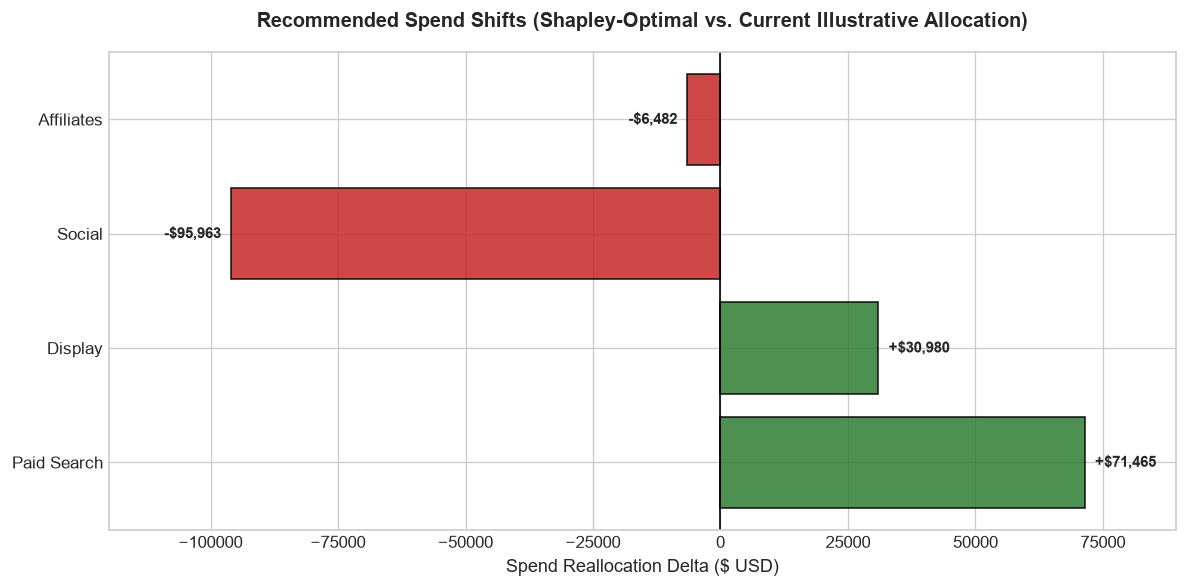

In [3]:
df_opt = pd.read_csv('data/exports/budget_optimizer.csv')
print("=== SHAPLEY-PROPORTIONAL BUDGET REALLOCATION (ILLUSTRATIVE) ===")
print("Constraint: Fixed total paid budget. Allocation proportional to Shapley contribution weight.\n")
display(df_opt)

# Budget Delta Bar Chart
plt.figure(figsize=(10, 5))
channels = df_opt['Channel']
deltas = df_opt['Spend_Delta']
colors = ['#2e7d32' if d >= 0 else '#c62828' for d in deltas]

bars = plt.barh(channels, deltas, color=colors, alpha=0.85, edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.title('Recommended Spend Shifts (Shapley-Optimal vs. Current Illustrative Allocation)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Spend Reallocation Delta ($ USD)', fontsize=11)

for bar in bars:
    width = bar.get_width()
    label = f"+${width:,.0f}" if width >= 0 else f"-${abs(width):,.0f}"
    plt.text(width + (2000 if width >= 0 else -2000), bar.get_y() + bar.get_height()/2, 
             label, va='center', ha='left' if width >= 0 else 'right', fontsize=9, fontweight='bold')

plt.xlim(min(deltas)*1.25, max(deltas)*1.25)
plt.tight_layout()
plt.savefig('data/exports/budget_reallocation_chart.png', dpi=150)
plt.show()


---
## 3. What-If Scenario Simulator


In [4]:
df_sim = pd.read_csv('data/exports/what_if_scenarios.csv')
print("=== WHAT-IF SCENARIOS (LINEAR SCALING, ILLUSTRATIVE SPEND) ===")
print("NOTE: Linear scaling ignores diminishing returns — directional guidance only.\n")
display(df_sim)


=== WHAT-IF SCENARIOS (LINEAR SCALING, ILLUSTRATIVE SPEND) ===
NOTE: Linear scaling ignores diminishing returns — directional guidance only.



,Channel,Scenario,Current_Spend,Proposed_Spend,Spend_Delta,Current_Shapley_Conv,Projected_Conv,Conv_Delta,Revenue_Impact
0,Paid Search,70% of current,26160.0,18312.0,-7848.0,169.50,118.65,-50.85,-6900.27
1,Display,150% of current,1561.2,2341.8,780.6,56.50,84.75,28.25,3833.48
2,Social,50% of current,113916.0,56958.0,-56958.0,31.17,15.58,-15.58,-2114.86


---
## 4. Markov Chain Network Flow Visualization
Renders the SQL-computed transition probability matrix as a directed graph. Low-probability noise edges (< 3%) are filtered for visual clarity.


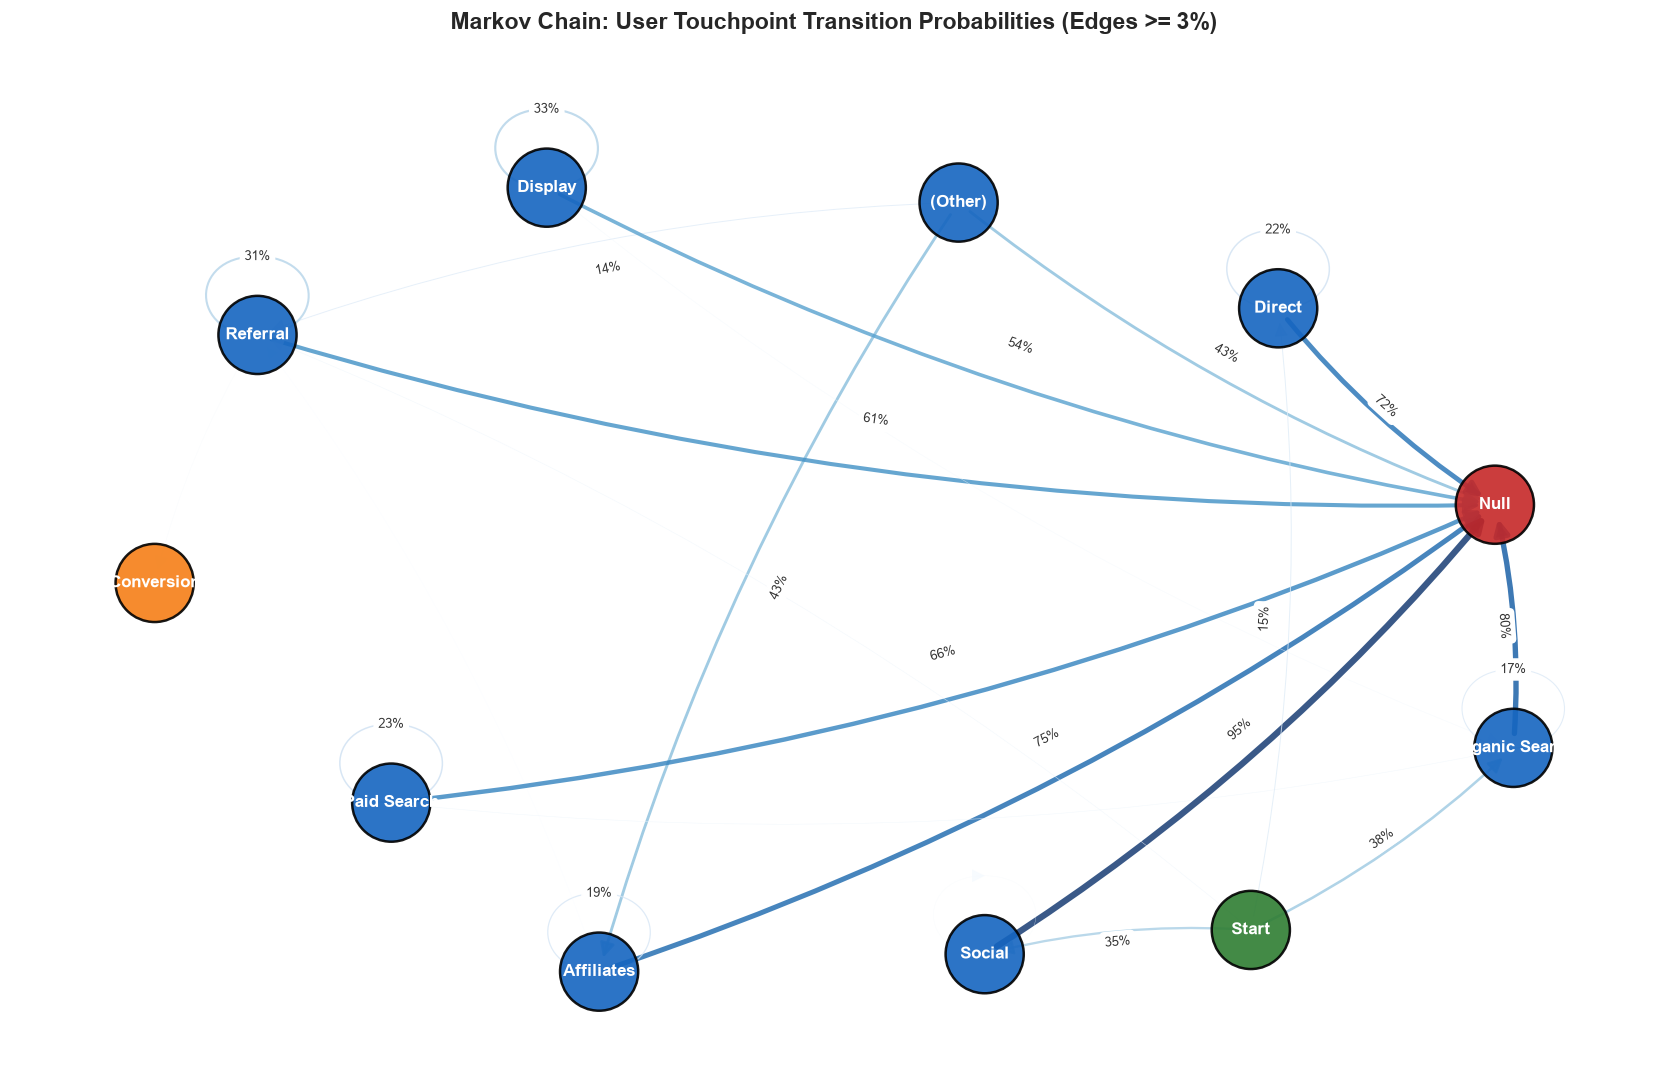

In [5]:
df_trans = pd.read_csv('data/exports/fact_channel_transitions.csv')

G = nx.DiGraph()
trans_matrix = defaultdict(lambda: defaultdict(int))
for _, r in df_trans.iterrows():
    trans_matrix[r['from_channel']][r['to_channel']] = r['transition_count']

for orig, dests in trans_matrix.items():
    total_out = sum(dests.values())
    for dest, count in dests.items():
        prob = count / total_out if total_out > 0 else 0
        if prob >= 0.03:
            G.add_edge(orig, dest, weight=prob)

node_colors = []
for node in G.nodes():
    if node == 'Start': node_colors.append('#2e7d32')
    elif node == 'Conversion': node_colors.append('#f57f17')
    elif node == 'Null': node_colors.append('#c62828')
    else: node_colors.append('#1565c0')

plt.figure(figsize=(14, 9))
pos = nx.spring_layout(G, k=1.8, seed=42)

edges = G.edges()
weights = [G[u][v]['weight'] * 4 for u, v in edges]
edge_colors = [G[u][v]['weight'] for u, v in edges]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2200, alpha=0.9, edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='white')
nx.draw_networkx_edges(G, pos, width=weights, edge_color=edge_colors, edge_cmap=plt.cm.Blues, 
                       arrowsize=18, connectionstyle='arc3,rad=0.08', alpha=0.8)

edge_labels = {}
for u, v in edges:
    w = G[u][v]['weight']
    if w >= 0.10:
        edge_labels[(u, v)] = f"{w:.0%}"

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color='#333333')

plt.title('Markov Chain: User Touchpoint Transition Probabilities (Edges >= 3%)', fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig('data/exports/markov_chain_network_graph.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Summary
After executing all cells above, the `data/exports/` directory contains:
- `model_comparison.csv` — 6-model attribution comparison
- `financial_reconciliation.csv` — Illustrative CPA/ROAS reconciliation
- `budget_optimizer.csv` — Shapley-proportional reallocation recommendation
- `what_if_scenarios.csv` — Linear-scaled scenario projections
- `budget_reallocation_chart.png` — Diverging bar chart
- `markov_chain_network_graph.png` — Directed network graph

